In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
import matplotlib.ticker as ticker
from sklearn.model_selection import (
    KFold,
    cross_validate,
    cross_val_score,
    train_test_split,
    learning_curve,
    cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)
pd.set_option('display.float_format', '{:.2f}'.format) 

In [2]:
# Loading dataset
df = pd.read_excel("../data/Sydney_house_price.xlsx")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (120, 12)


,S.no,Address,Locality,Sale_date,Sell_price,Bed,Bath,Parking,Propert_type,Distance_from_school_in_kms,Property_description,Data_source
0,1,"3/6 Brierley Street, Mosman NSW 2088",Mosman,2026-08-04,975000,2,1,NaN,Apartment / Unit / Flat,1.10,"Tucked away in the boutique 'Carmel' block, this charming apartment presents an effortless blend...",www.domain.com.au
1,2,"11/23 Warringah Road, Mosman NSW 2088",Mosman,2026-07-31,865000,1,1,1.00,Apartment / Unit / Flat,0.70,"Holding a prized position in a boutique security building, this renovated apartment captures stu...",www.domain.com.au
2,3,"142/15 Hale Road, Mosman NSW 2088",Mosman,2026-07-24,3800000,3,2,2.00,House,0.20,"Redefining expectations for over 55s living, this premier villa within the prestigious 'The Mano...",www.domain.com.au
3,4,"5 Botanic Road, Mosman NSW 2088",Mosman,2026-07-22,8700000,4,3,2.00,House,0.50,Just a short and level stroll to the sand of Balmoral Beach and set in the most private and tran...,www.domain.com.au
4,5,"8/6 Punch Street, Mosman NSW 2088",Mosman,2026-07-20,700000,1,1,NaN,Apartment / Unit / Flat,0.60,"Quietly positioned at the rear of a well maintained building, this one-bedroom apartment deliver...",www.domain.com.au


# Data Overview

In [3]:
# Dataset dimensions
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 120
Number of columns: 12


In [4]:
# Column names
print("Columns:")
df.columns

Columns:


Index(['S.no', 'Address', 'Locality', 'Sale_date', 'Sell_price', 'Bed', 'Bath',
       'Parking ', 'Propert_type', 'Distance_from_school_in_kms',
       'Property_description', 'Data_source'],
      dtype='object')

There is currently a trailing space in Parking and need for standardising the column names.

In [5]:
# Data types
df.dtypes

S.no                                    int64
Address                                object
Locality                               object
Sale_date                      datetime64[ns]
Sell_price                              int64
Bed                                     int64
Bath                                    int64
Parking                               float64
Propert_type                           object
Distance_from_school_in_kms           float64
Property_description                   object
Data_source                            object
dtype: object

In [6]:
# Basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   S.no                         120 non-null    int64         
 1   Address                      120 non-null    object        
 2   Locality                     120 non-null    object        
 3   Sale_date                    120 non-null    datetime64[ns]
 4   Sell_price                   120 non-null    int64         
 5   Bed                          120 non-null    int64         
 6   Bath                         120 non-null    int64         
 7   Parking                      110 non-null    float64       
 8   Propert_type                 120 non-null    object        
 9   Distance_from_school_in_kms  120 non-null    float64       
 10  Property_description         119 non-null    object        
 11  Data_source                  120 non-null    

In [7]:
# Number of unique values in each column
df.nunique().sort_values()

Data_source                      1
Locality                         3
Bath                             4
Parking                          4
Propert_type                     4
Bed                              7
Distance_from_school_in_kms     13
Sale_date                       46
Sell_price                     104
Property_description           119
S.no                           120
Address                        120
dtype: int64

Propert_type should have only 3 unique enteries, however, our analysis is showing 4 unique entries which needds to be checked since there could be some typing mistake or inconsistent entry.
# Data Cleaning

In [8]:
# Removing leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Rename columns for clarity and consistency
df = df.rename(columns={
    "Propert_type": "Property_type",
    "Distance_from_school_in_kms": "Distance_from_school_km"
})

df.columns

Index(['S.no', 'Address', 'Locality', 'Sale_date', 'Sell_price', 'Bed', 'Bath',
       'Parking', 'Property_type', 'Distance_from_school_km',
       'Property_description', 'Data_source'],
      dtype='object')

In [9]:
print(df["Property_type"].unique())

['Apartment / Unit / Flat' 'House' 'Townhouse' 'apartment / Unit / Flat']


We identified that the dataset contains both:

* Apartment / Unit / Flat
* apartment / Unit / Flat

These should be treated as the same category.

In [10]:
# Standardise property type text
df["Property_type"] = df["Property_type"].str.strip()

df["Property_type"] = df["Property_type"].replace({
    "apartment / Unit / Flat": "Apartment / Unit / Flat"
})

df["Property_type"].value_counts()

Property_type
Apartment / Unit / Flat    79
House                      36
Townhouse                   5
Name: count, dtype: int64

In [11]:
print("Number of property types:", df["Property_type"].nunique())
print(df["Property_type"].unique())

Number of property types: 3
['Apartment / Unit / Flat' 'House' 'Townhouse']


In [12]:
# Missing values
missing = pd.DataFrame({
    "Missing_count": df.isna().sum(),
    "Missing_percentage": (df.isna().mean() * 100).round(2)
})

missing.sort_values("Missing_count", ascending=False)

,Missing_count,Missing_percentage
Parking,10,8.33
Property_description,1,0.83
S.no,0,0.00
Address,0,0.00
Locality,0,0.00
Sale_date,0,0.00
Sell_price,0,0.00
Bed,0,0.00
Bath,0,0.00
Property_type,0,0.00


In [13]:
df[df["Parking"].isna()][
    ["Locality", "Property_type", "Bed", "Bath", "Sell_price", "Property_description"]
]

,Locality,Property_type,Bed,Bath,Sell_price,Property_description
0,Mosman,Apartment / Unit / Flat,2,1,975000,"Tucked away in the boutique 'Carmel' block, this charming apartment presents an effortless blend..."
4,Mosman,Apartment / Unit / Flat,1,1,700000,"Quietly positioned at the rear of a well maintained building, this one-bedroom apartment deliver..."
8,Mosman,Apartment / Unit / Flat,2,1,990000,"Tucked away peacefully in a well maintained boutique block, this enticing first floor apartment ..."
10,Mosman,House,4,2,3225000,"Offering the best of quiet convenience, this inviting four-bedroom Federation beauty has been ta..."
22,Mosman,House,4,3,3550000,"Brimming with enduring charm and classic elegance, this inviting full brick terrace marries thou..."
28,Mosman,Apartment / Unit / Flat,2,1,1140000,"Embracing a lifestyle of simplistic luxury, this effortlessly chic apartment is positioned on th..."
33,Mosman,Apartment / Unit / Flat,1,1,800000,"Perched high on the prestigious Balmoral Slopes, this light-filled apartment encapsulates the qu..."
83,Parramatta,Apartment / Unit / Flat,1,1,623000,"Elevated high on level 36 within Parramatta's most prestigious riverfront address, this exceptio..."
90,Parramatta,Apartment / Unit / Flat,1,1,497000,We've been overwhelmed by the amount of interest in similar properties. If you are considering s...
111,Parramatta,Apartment / Unit / Flat,1,1,350000,"Positioned in a prime central location, this well-appointed 1-bedroom apartment offers the perfe..."


Here we have checked the missing values, however, we will not treat them yet. First we will further understand the dataset. 
# Exploratory Data Analysis

In [14]:
# numeric variables
numeric_columns = [
    "Sell_price",
    "Bed",
    "Bath",
    "Parking",
    "Distance_from_school_km"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Sell_price,120.00,1317133.32,1437328.83,350000.00,621000.00,848500.00,1205250.00,8700000.00
Bed,120.00,2.50,1.09,1.00,2.00,2.00,3.00,7.00
Bath,120.00,1.62,0.71,1.00,1.00,2.00,2.00,4.00
Parking,110.00,1.39,0.64,1.00,1.00,1.00,2.00,4.00
Distance_from_school_km,120.00,0.55,0.32,0.10,0.30,0.50,0.70,1.60


In [15]:
# categorical variables
categorical_columns = [
    "Locality",
    "Property_type"
]

for column in categorical_columns:
    print("\n" + "=" * 60)
    print(column)
    print("=" * 60)
    print(df[column].value_counts())


Locality
Locality
Mosman        40
Blacktown     40
Parramatta    40
Name: count, dtype: int64

Property_type
Property_type
Apartment / Unit / Flat    79
House                      36
Townhouse                   5
Name: count, dtype: int64


In [16]:
# distribution of housing prices
price_summary = df["Sell_price"].describe()
print("distribution of housing prices")
print(price_summary)

distribution of housing prices
count       120.00
mean    1317133.32
std     1437328.83
min      350000.00
25%      621000.00
50%      848500.00
75%     1205250.00
max     8700000.00
Name: Sell_price, dtype: float64


In [17]:
# calculating skewness
price_skewness = skew(df["Sell_price"])
print("Price skewness:", round(price_skewness, 3))

Price skewness: 3.133


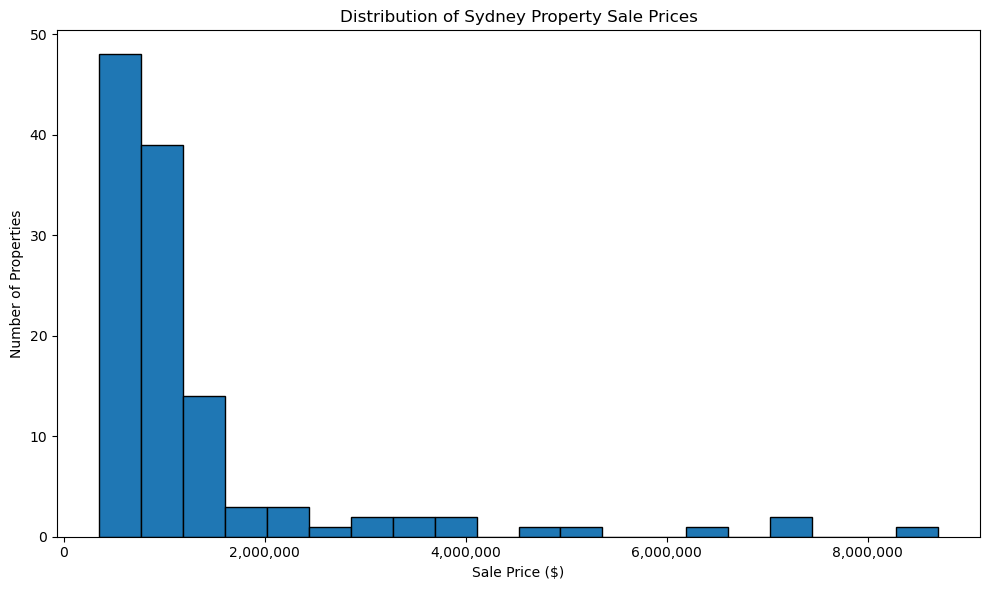

In [18]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Sell_price"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Sydney Property Sale Prices")
plt.xlabel("Sale Price ($)")
plt.ylabel("Number of Properties")
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

Property prices are heavily right skewed which is evident from the histogram meaning sale price could have outliers which we would check using boxplot.

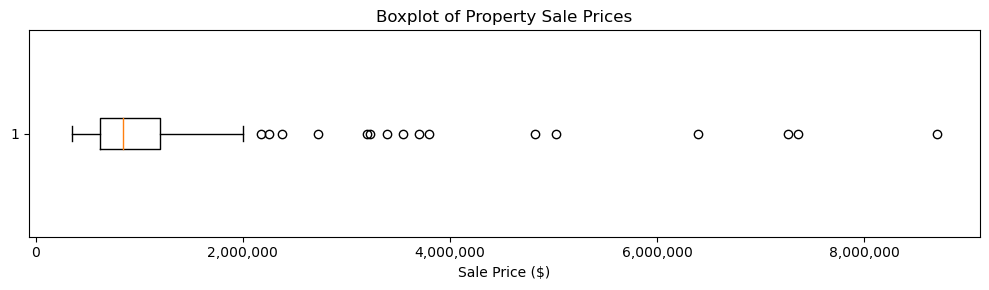

In [19]:
plt.figure(figsize=(10, 3))

plt.boxplot(
    df["Sell_price"],
    vert=False
)

plt.title("Boxplot of Property Sale Prices")
plt.xlabel("Sale Price ($)")
plt.gca().xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

Boxplot confirms presence of outliers, to understand the price distribution better we would check the descriptive statistics based on locality.

In [20]:
# comparing property prices across suburbs
suburb_price_summary = (
    df.groupby("Locality")["Sell_price"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median",
          Minimum="min",
          Maximum="max",
          Std_Dev="std"
      )
      .round(2)
)

suburb_price_summary

,Count,Mean,Median,Minimum,Maximum,Std_Dev
Locality,,,,,,
Blacktown,40,861162.48,942500.00,380000,1700000,320960.75
Mosman,40,2450462.50,1510000.00,700000,8700000,2045491.62
Parramatta,40,639775.00,645000.00,350000,880000,124284.31


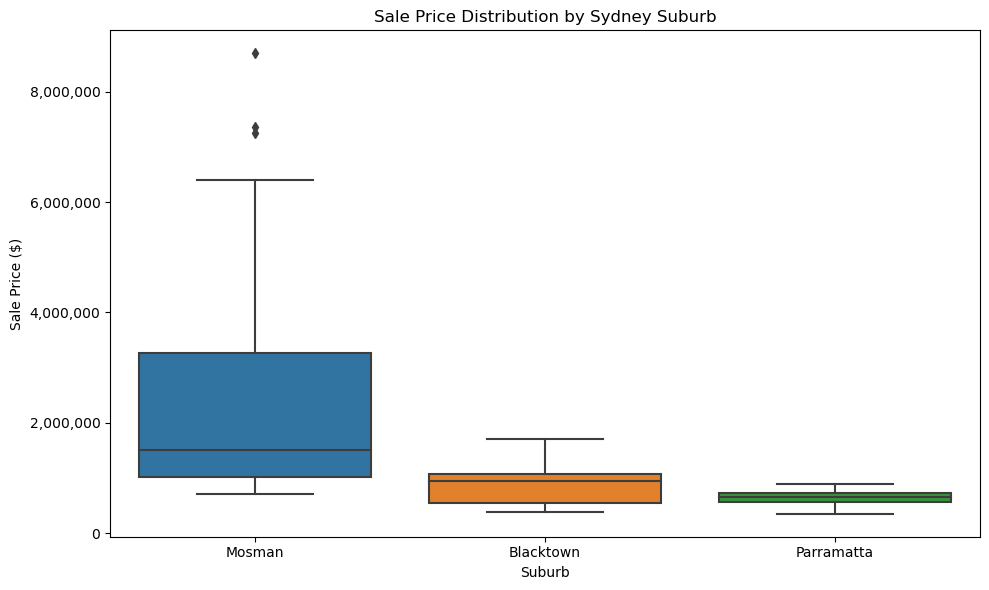

In [21]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Locality",
    y="Sell_price"
)

plt.title("Sale Price Distribution by Sydney Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

The right skewness in our data is coming from Mosman whose price distribution is far more spread out then other 2 localities.

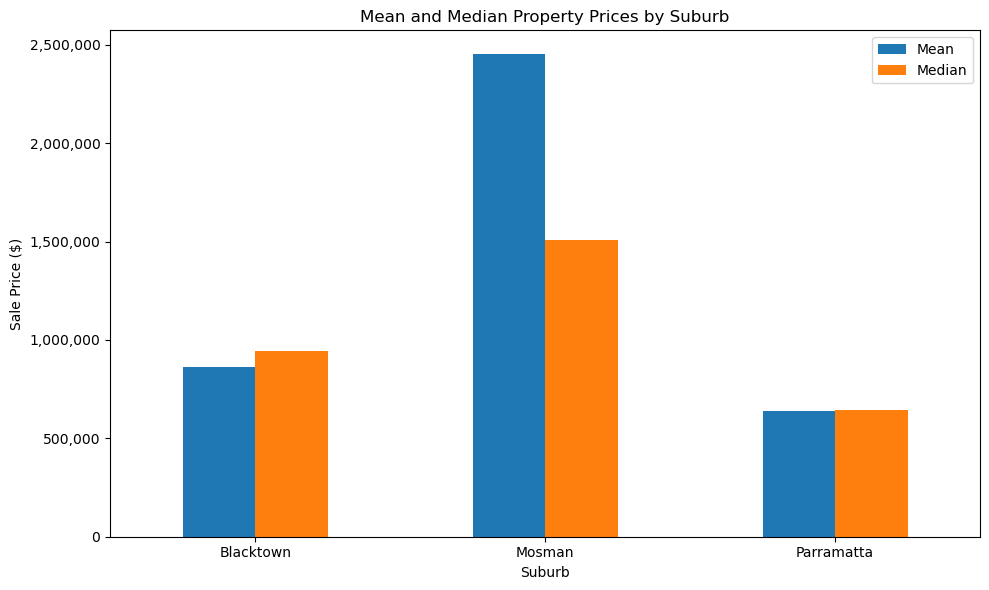

In [22]:
suburb_price_summary[["Mean", "Median"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Mean and Median Property Prices by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price ($)")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

Because property prices can be heavily skewed specially in case of Mosman we can see huge difference between mean and median for it while for other 2 localities mean and median are far more symmetric.

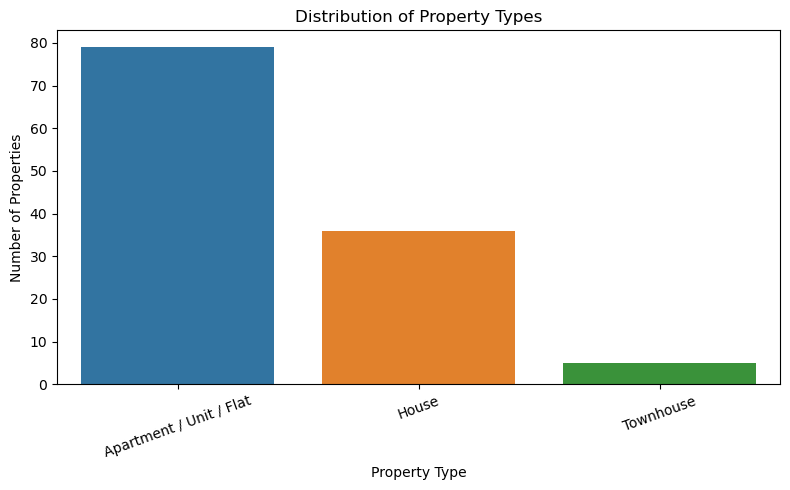

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Property_type"
)

plt.title("Distribution of Property Types")
plt.xlabel("Property Type")
plt.ylabel("Number of Properties")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [24]:
property_type_suburb = pd.crosstab(
    df["Locality"],
    df["Property_type"]
)

property_type_suburb

Property_type,Apartment / Unit / Flat,House,Townhouse
Locality,,,
Blacktown,15,24,1
Mosman,25,12,3
Parramatta,39,0,1


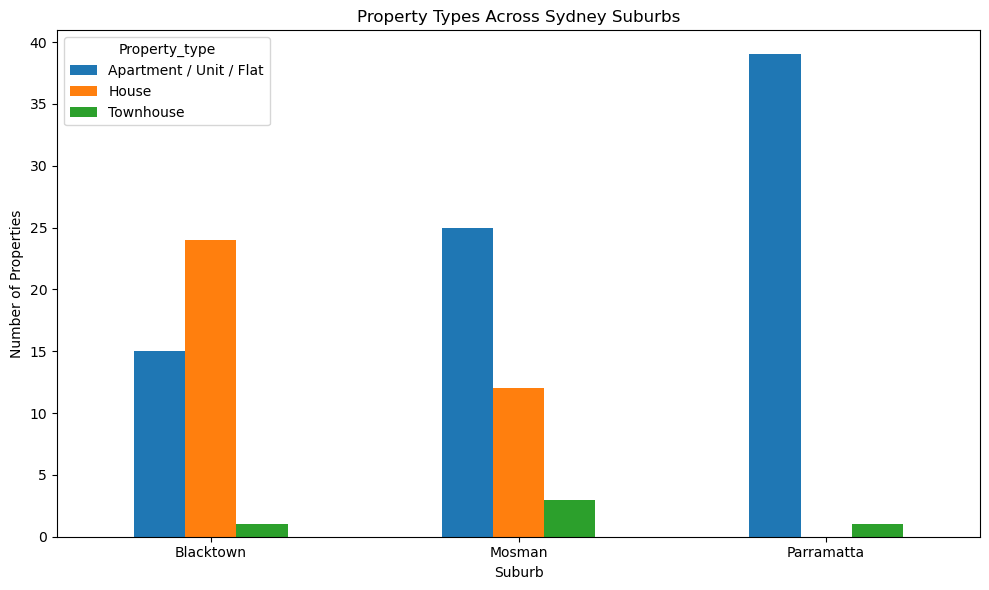

In [25]:
property_type_suburb.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Property Types Across Sydney Suburbs")
plt.xlabel("Suburb")
plt.ylabel("Number of Properties")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

Based on the locality the property types vary which means dataset is not perfectly balanced by property type.

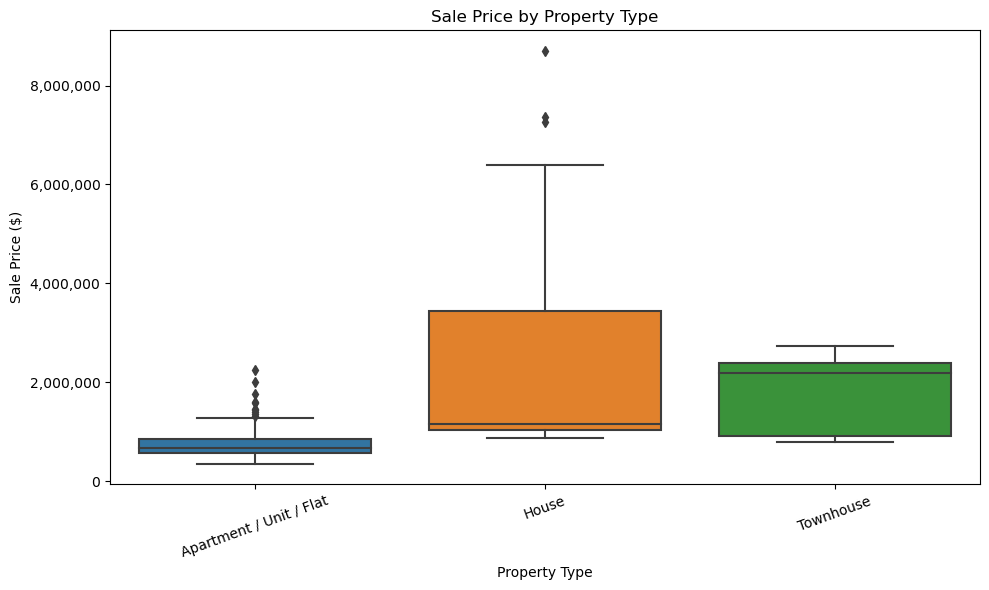

In [26]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Property_type",
    y="Sell_price"
)

plt.title("Sale Price by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

While houses have significantly higher sale price and Apartment / Unit / Flat have the lowest still Mosman has significantly higher price distribution despite having recorded higher sales of Apartment / Unit / Flat then other 2 property types, conversely, Blacktown has seen higher house sale and still its price distribution is comparatively consistent.

In [27]:
property_type_summary = (
    df.groupby("Property_type")["Sell_price"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median",
          Minimum="min",
          Maximum="max"
      )
      .round(2)
)

property_type_summary

,Count,Mean,Median,Minimum,Maximum
Property_type,,,,,
Apartment / Unit / Flat,79,792196.20,667000.00,350000,2250000
House,36,2402430.53,1160000.00,865000,8700000
Townhouse,5,1797000.00,2180000.00,780000,2725000


In [28]:
# Price trends over time
df["Sale_date"] = pd.to_datetime(df["Sale_date"])

print("Earliest sale:", df["Sale_date"].min())
print("Latest sale:", df["Sale_date"].max())

Earliest sale: 2026-05-19 00:00:00
Latest sale: 2026-08-13 00:00:00


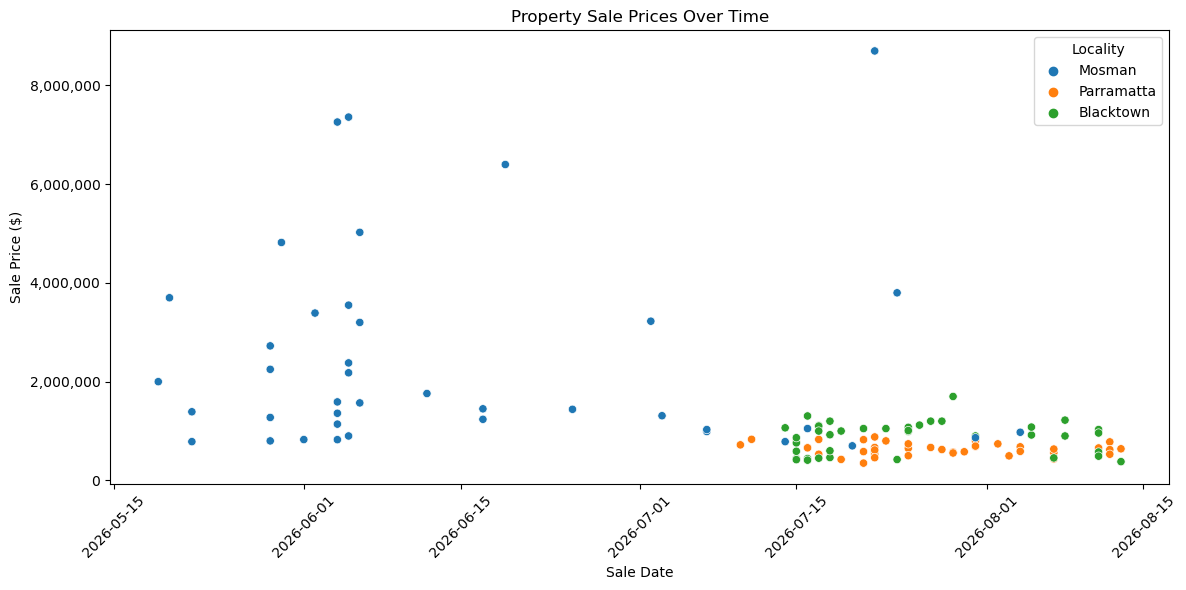

In [29]:
df = df.sort_values("Sale_date").reset_index(drop=True)
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=df,
    x="Sale_date",
    y="Sell_price",
    hue="Locality"
)

plt.title("Property Sale Prices Over Time")
plt.xlabel("Sale Date")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Based on sale date a clear trend is appearing where maximum higher priced properties most of which belongs to Mosman were sold in months of May and June, in fact, sales of properties from Parramatta and Blacktown are clustered in July and August with few from Mosman during this period.

In [30]:
df["Sale_month"] = df["Sale_date"].dt.to_period("M").astype(str)

monthly_summary = (
    df.groupby("Sale_month")["Sell_price"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median"
      )
      .round(2)
)

monthly_summary

,Count,Mean,Median
Sale_month,,,
2026-05,9,2193888.89,2000000.00
2026-06,20,2742175.00,1675000.00
2026-07,68,986992.63,782500.00
2026-08,23,710956.52,640000.00


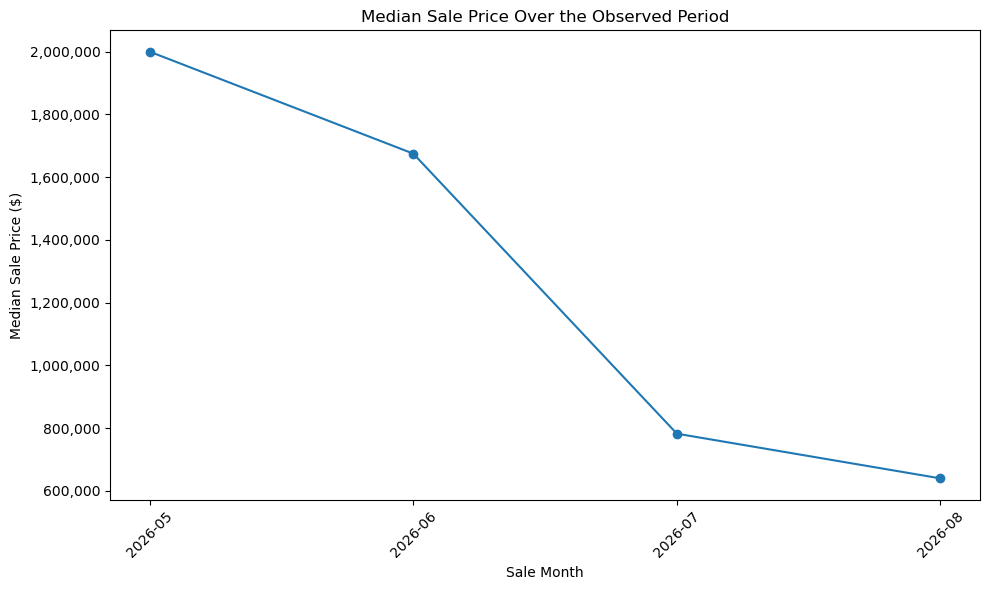

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_summary.index,
    monthly_summary["Median"],
    marker="o"
)

plt.title("Median Sale Price Over the Observed Period")
plt.xlabel("Sale Month")
plt.ylabel("Median Sale Price ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Since during May and June most properties sold as per our dataset belongs to Mosman which has a higher sale price due to which for these 2 months median sale price is higher which drops down significantly in July as other 2 localities sales data comes in.

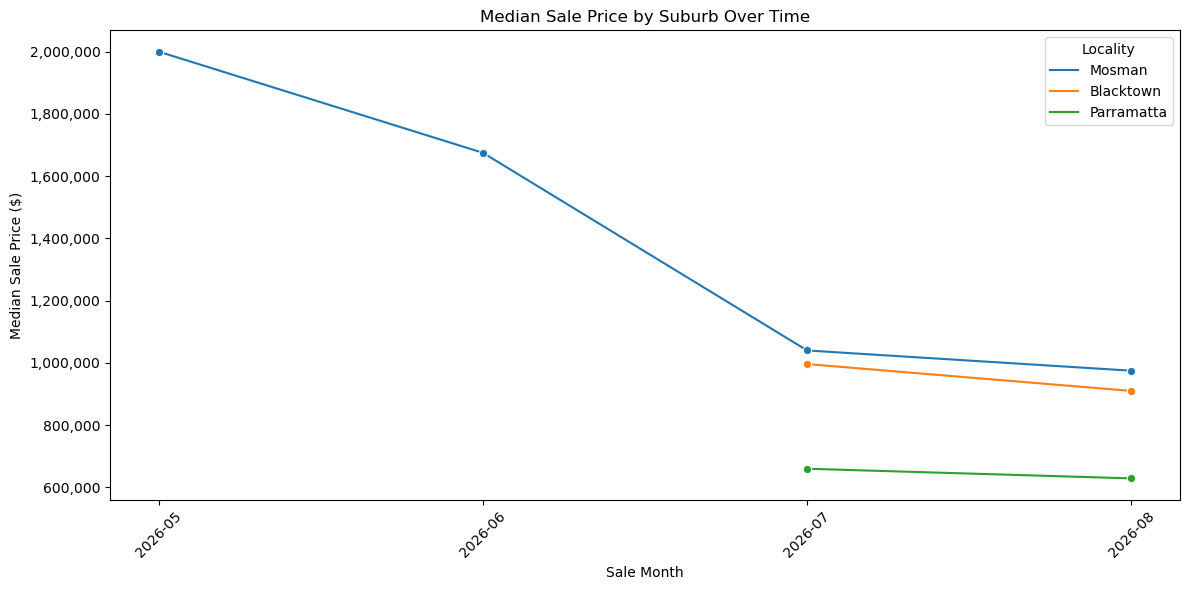

In [32]:
monthly_suburb = (
    df.groupby(["Sale_month", "Locality"])["Sell_price"]
      .median()
      .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_suburb,
    x="Sale_month",
    y="Sell_price",
    hue="Locality",
    marker="o"
)

plt.title("Median Sale Price by Suburb Over Time")
plt.xlabel("Sale Month")
plt.ylabel("Median Sale Price ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

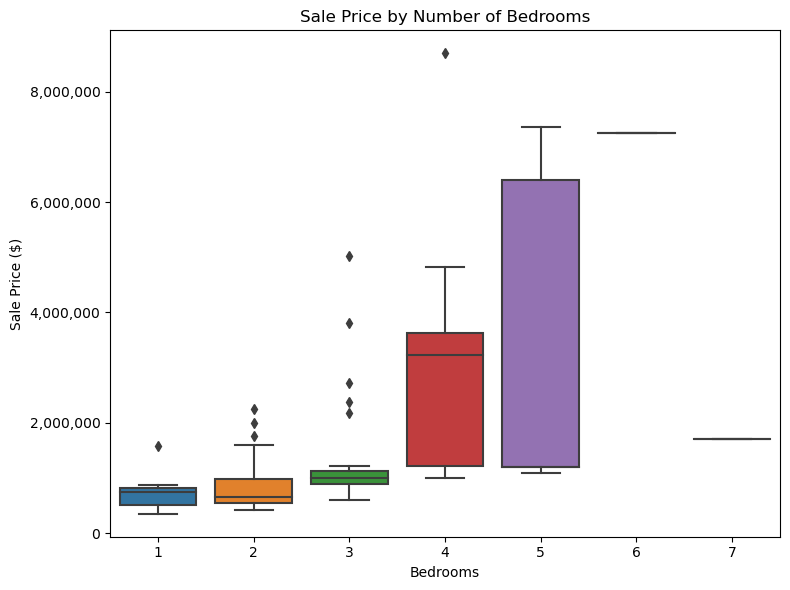

In [33]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Bed",
    y="Sell_price"
)

plt.title("Sale Price by Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

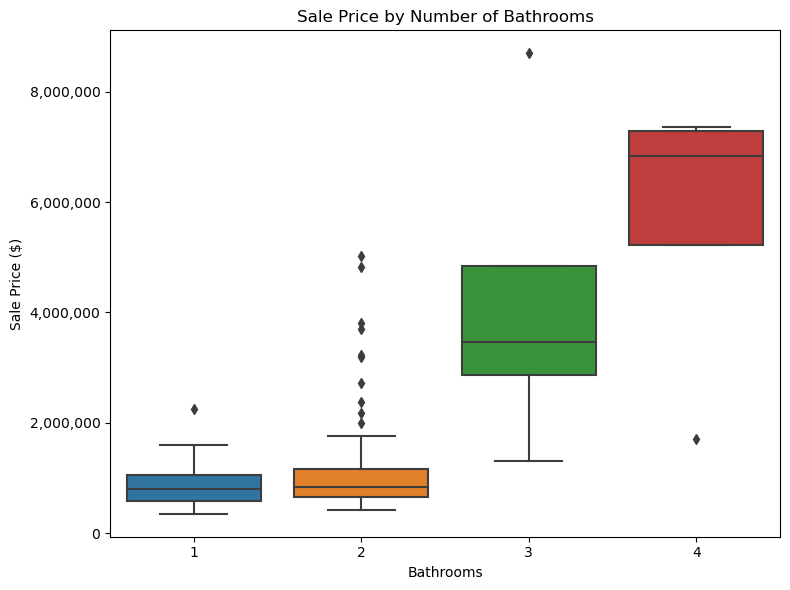

In [34]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Bath",
    y="Sell_price"
)

plt.title("Sale Price by Number of Bathrooms")
plt.xlabel("Bathrooms")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

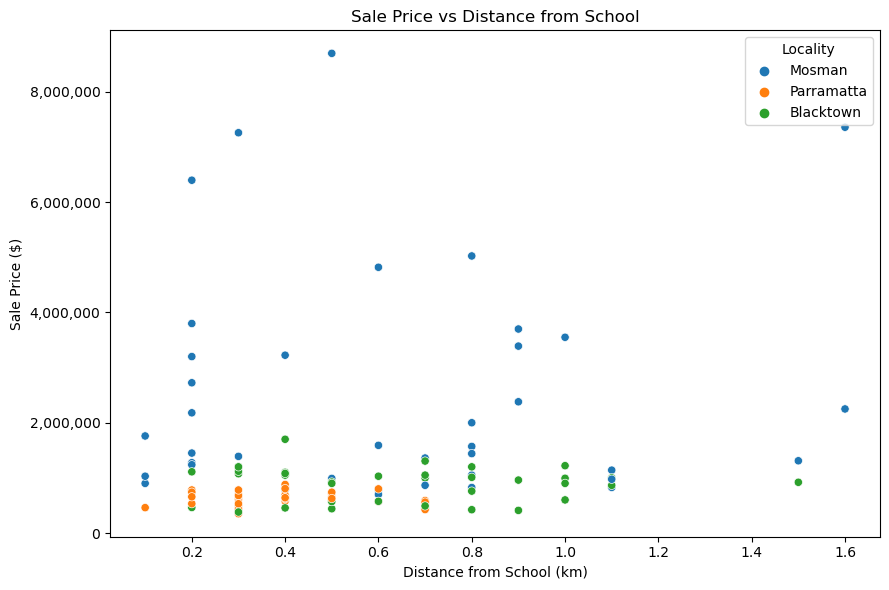

In [35]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Distance_from_school_km",
    y="Sell_price",
    hue="Locality"
)

plt.title("Sale Price vs Distance from School")
plt.xlabel("Distance from School (km)")
plt.ylabel("Sale Price ($)")
plt.gca().yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

On comparing sale price to numeric variables like number of bedrooms and bathrooms there seems to be a positive correlation between these variables that is as the number of bedrooms and bathrooms so does the sale price while Distance from School (km) appears to have a negative correlation that is closer a property is to a school, higher its sale price. To understand this relationship better we would perform a correlation analysis.

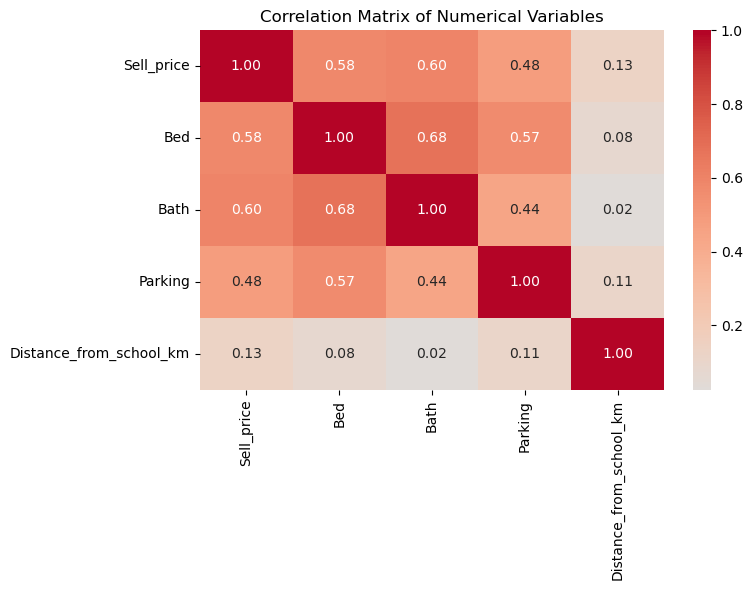

In [36]:
correlation_columns = [
    "Sell_price",
    "Bed",
    "Bath",
    "Parking",
    "Distance_from_school_km"
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

Sell price is having positive correlation to numeric variables like bed, bath and parking while with Distance from School (km) it is very low.

In [37]:
# detecting statistical outliers
Q1 = df["Sell_price"].quantile(0.25)
Q3 = df["Sell_price"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 621000.0
Q3: 1205250.0
IQR: 584250.0
Lower bound: -255375.0
Upper bound: 2081625.0


In [38]:
price_outliers = df[
    (df["Sell_price"] < lower_bound) |
    (df["Sell_price"] > upper_bound)
].copy()

print("Number of statistical price outliers:", len(price_outliers))

price_outliers[
    [
        "Address",
        "Locality",
        "Sale_date",
        "Sell_price",
        "Bed",
        "Bath",
        "Parking",
        "Property_type"
    ]
].sort_values("Sell_price", ascending=False)

Number of statistical price outliers: 16


,Address,Locality,Sale_date,Sell_price,Bed,Bath,Parking,Property_type
67,"5 Botanic Road, Mosman NSW 2088",Mosman,2026-07-22,8700000,4,3,2.00,House
19,"2 Morella Road, Mosman NSW 2088",Mosman,2026-06-05,7360000,5,4,4.00,House
12,"11 Euryalus Street, Mosman NSW 2088",Mosman,2026-06-04,7260000,6,4,3.00,House
27,"5 Central Avenue, Mosman NSW 2088",Mosman,2026-06-19,6399000,5,4,2.00,House
21,"14 Almora Street, Mosman NSW 2088",Mosman,2026-06-06,5025000,3,2,2.00,House
8,"14 Calypso Avenue, Mosman NSW 2088",Mosman,2026-05-30,4820000,4,2,2.00,House
75,"142/15 Hale Road, Mosman NSW 2088",Mosman,2026-07-24,3800000,3,2,2.00,House
1,"14 Dalton Road, Mosman NSW 2088",Mosman,2026-05-20,3700000,4,2,1.00,House
17,"105 Holt Avenue, Mosman NSW 2088",Mosman,2026-06-05,3550000,4,3,NaN,House
10,"96 Glover Street, Mosman NSW 2088",Mosman,2026-06-02,3390000,4,3,2.00,House


In [39]:
# Outliers by suburb
def identify_iqr_outliers(group):
    q1 = group["Sell_price"].quantile(0.25)
    q3 = group["Sell_price"].quantile(0.75)
    iqr = q3 - q1
    
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    return group[
        (group["Sell_price"] < lower) |
        (group["Sell_price"] > upper)
    ]

suburb_outliers = (
    df.groupby("Locality", group_keys=False)
      .apply(identify_iqr_outliers)
)

suburb_outliers[
    [
        "Address",
        "Locality",
        "Sale_date",
        "Sell_price",
        "Bed",
        "Bath",
        "Property_type"
    ]
].sort_values("Sell_price", ascending=False)

,Address,Locality,Sale_date,Sell_price,Bed,Bath,Property_type
67,"5 Botanic Road, Mosman NSW 2088",Mosman,2026-07-22,8700000,4,3,House
19,"2 Morella Road, Mosman NSW 2088",Mosman,2026-06-05,7360000,5,4,House
12,"11 Euryalus Street, Mosman NSW 2088",Mosman,2026-06-04,7260000,6,4,House


When we studied outliers for all properties we found 16 outliers, however, when diffrentiated based on suburbs the numbers come down to 3 with outliers in both cases belonging to Mosman only this is due to the fact that since prices in Mosman are higher, median price is also higher due to which IQR range also increases bringing down the number of outliers

In [40]:
# Investigating the highest-priced properties
df.nlargest(
    10,
    "Sell_price"
)[
    [
        "Address",
        "Locality",
        "Sale_date",
        "Sell_price",
        "Bed",
        "Bath",
        "Parking",
        "Property_type",
        "Distance_from_school_km"
    ]
]

,Address,Locality,Sale_date,Sell_price,Bed,Bath,Parking,Property_type,Distance_from_school_km
67,"5 Botanic Road, Mosman NSW 2088",Mosman,2026-07-22,8700000,4,3,2.00,House,0.50
19,"2 Morella Road, Mosman NSW 2088",Mosman,2026-06-05,7360000,5,4,4.00,House,1.60
12,"11 Euryalus Street, Mosman NSW 2088",Mosman,2026-06-04,7260000,6,4,3.00,House,0.30
27,"5 Central Avenue, Mosman NSW 2088",Mosman,2026-06-19,6399000,5,4,2.00,House,0.20
21,"14 Almora Street, Mosman NSW 2088",Mosman,2026-06-06,5025000,3,2,2.00,House,0.80
8,"14 Calypso Avenue, Mosman NSW 2088",Mosman,2026-05-30,4820000,4,2,2.00,House,0.60
75,"142/15 Hale Road, Mosman NSW 2088",Mosman,2026-07-24,3800000,3,2,2.00,House,0.20
1,"14 Dalton Road, Mosman NSW 2088",Mosman,2026-05-20,3700000,4,2,1.00,House,0.90
17,"105 Holt Avenue, Mosman NSW 2088",Mosman,2026-06-05,3550000,4,3,NaN,House,1.00
10,"96 Glover Street, Mosman NSW 2088",Mosman,2026-06-02,3390000,4,3,2.00,House,0.90


### Identify the three variables BEFORE feature engineering
#### Initial hypothesis

Before feature engineering, the three variables expected to have the strongest influence on sale price are:

1. Locality — the three suburbs represent substantially different housing markets, so location is expected to create a major difference in property values.
2. Bedrooms — bedroom count provides an indication of property size and accommodation capacity and is therefore expected to have a strong positive relationship with price.
3. Bathrooms — bathroom count is associated with property size, functionality and property quality and is expected to provide additional information about market value.

In [41]:
df["Sale_year"] = df["Sale_date"].dt.year
df["Sale_month_num"] = df["Sale_date"].dt.month
df["Sale_quarter"] = df["Sale_date"].dt.quarter

In [42]:
df["Bath_per_Bed"] = df["Bath"] / df["Bed"].replace(0, np.nan)

df[
    [
        "Bed",
        "Bath",
        "Bath_per_Bed"
    ]
].head()

,Bed,Bath,Bath_per_Bed
0,2,2,1.00
1,4,2,0.50
2,2,1,0.50
3,1,1,1.00
4,1,1,1.00


In [43]:
df["Bed_Bath_Total"] = df["Bed"] + df["Bath"]

df[
    [
        "Bed",
        "Bath",
        "Bed_Bath_Total"
    ]
].head()

,Bed,Bath,Bed_Bath_Total
0,2,2,4
1,4,2,6
2,2,1,3
3,1,1,2
4,1,1,2


In [44]:
engineered_columns = [
    "Bed",
    "Bath",
    "Bath_per_Bed",
    "Bed_Bath_Total",
    "Sale_year",
    "Sale_month_num",
    "Sale_quarter"
]

df[engineered_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Bed,120.00,2.50,1.09,1.00,2.00,2.00,3.00,7.00
Bath,120.00,1.62,0.71,1.00,1.00,2.00,2.00,4.00
Bath_per_Bed,120.00,0.70,0.25,0.25,0.50,0.67,1.00,1.00
Bed_Bath_Total,120.00,4.12,1.66,2.00,3.00,4.00,5.00,11.00
Sale_year,120.00,2026.00,0.00,2026.00,2026.00,2026.00,2026.00,2026.00
Sale_month_num,120.00,6.88,0.81,5.00,7.00,7.00,7.00,8.00
Sale_quarter,120.00,2.76,0.43,2.00,3.00,3.00,3.00,3.00


In [45]:
df[engineered_columns + ["Sell_price"]].corr()["Sell_price"].sort_values(
    ascending=False
)

Sell_price        1.00
Bed_Bath_Total    0.64
Bath              0.60
Bed               0.58
Bath_per_Bed     -0.09
Sale_month_num   -0.42
Sale_quarter     -0.49
Sale_year          NaN
Name: Sell_price, dtype: float64

By combining bed and bath we are able to build a feature that is actually stronger in correlation terms then the 2 individually.

In [46]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isna().sum())

print("\nProperty types:")
print(df["Property_type"].value_counts())

print("\nSuburbs:")
print(df["Locality"].value_counts())

print("\nDate range:")
print(df["Sale_date"].min(), "to", df["Sale_date"].max())

Final dataset shape: (120, 18)

Missing values:
S.no                        0
Address                     0
Locality                    0
Sale_date                   0
Sell_price                  0
Bed                         0
Bath                        0
Parking                    10
Property_type               0
Distance_from_school_km     0
Property_description        1
Data_source                 0
Sale_month                  0
Sale_year                   0
Sale_month_num              0
Sale_quarter                0
Bath_per_Bed                0
Bed_Bath_Total              0
dtype: int64

Property types:
Property_type
Apartment / Unit / Flat    79
House                      36
Townhouse                   5
Name: count, dtype: int64

Suburbs:
Locality
Mosman        40
Parramatta    40
Blacktown     40
Name: count, dtype: int64

Date range:
2026-05-19 00:00:00 to 2026-08-13 00:00:00


In [47]:
# Saving the processed dataset
processed_file = "..\\Data\\Sydney_house_price_processed.xlsx"

df.to_excel(
    processed_file,
    index=False
)

print(f"Processed dataset saved as: {processed_file}")

Processed dataset saved as: ..\Data\Sydney_house_price_processed.xlsx


# Extract features from Property_description

In [48]:
# Creating structured features from Property_description

df["Property_description"] = (
    df["Property_description"]
    .fillna("")
    .astype(str)
    .str.lower()
)

description_patterns = {
    "Has_pool": r"\bpool\b|swimming pool",
    "Has_garage": r"\bgarage\b|lock[- ]?up garage",
    "Has_balcony": r"\bbalcony\b",
    "Has_garden": r"\bgarden\b",
    "Has_views": r"\bviews?\b|water view|city view",
    "Has_renovated": r"\brenovat(?:ed|ion|ing)\b|refurbished|updated",
    "Has_aircon": r"air[- ]?conditioning|air[- ]?con",
    "Has_ensuite": r"\bensuite\b|en[- ]?suite",
    "Has_builtins": r"built[- ]?in|built in wardrobes?",
    "Has_courtyard": r"\bcourtyard\b"
}

for feature, pattern in description_patterns.items():
    df[feature] = (
        df["Property_description"]
        .str.contains(pattern, regex=True, na=False)
        .astype(int)
    )

In [49]:
description_features = list(description_patterns.keys())

df[description_features].sum().sort_values(ascending=False)

Has_builtins     85
Has_aircon       69
Has_balcony      64
Has_renovated    44
Has_ensuite      43
Has_garage       42
Has_views        34
Has_garden       22
Has_pool         15
Has_courtyard    14
dtype: int64

In [50]:
df[
    ["Property_description"] + description_features
].head().T

,0,1,2,3,4
Property_description,luxuriating in its leafy outlook to gardens and protected from lmr (low-mid rise housing) develo...,this elegant dual-level mosman residence blends charming federation character with a beautifully...,"harbourside living meets garden serenity in this house-like residence, one of only three in a ti...","capturing a prized north west aspect from the rear of a boutique block, this elevated ground flo...","perched high on the prestigious balmoral slopes, this light-filled apartment encapsulates the qu..."
Has_pool,0,0,0,0,0
Has_garage,0,0,0,0,0
Has_balcony,0,0,0,0,0
Has_garden,0,1,1,0,0
Has_views,0,0,0,0,0
Has_renovated,0,0,0,1,1
Has_aircon,1,1,0,1,0
Has_ensuite,1,0,0,1,0
Has_builtins,1,1,0,0,1


# Define the modelling variables

In [51]:
# Target
y = df["Sell_price"].copy()

# Predictor variables
numeric_features = [
    "Bed",
    "Bath",
    "Parking",
    "Distance_from_school_km",
    "Sale_year",
    "Sale_month_num",
    "Sale_quarter",
    "Bath_per_Bed",
    "Bed_Bath_Total"
] + description_features

categorical_features = [
    "Locality",
    "Property_type"
]

features = numeric_features + categorical_features

X = df[features].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (120, 21)
y shape: (120,)


# Building pre-processing pipeline

In [52]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

# Model building
For model building we would take:
1. Linear regression: Linear Regression provides an important baseline because it is simple and highly interpretable. However, it assumes that the relationship between the predictors and sale price can be represented adequately using a linear combination of the predictors. This assumption may be restrictive for the housing dataset because property prices are likely to be influenced by nonlinear relationships, differences between suburbs and interactions between property characteristics.
2. Decision Tree Regression: Decision Tree Regression is able to capture nonlinear relationships and interactions without requiring them to be specified manually. It can therefore model relationships that Linear Regression may fail to capture. However, an individual decision tree can become overly complex and fit the training observations too closely, particularly given the relatively small sample size.
3. Random Forest Regression: Random Forest Regression is expected to perform best because it combines predictions from many decision trees. This allows it to model nonlinear relationships and interactions while reducing some of the variance associated with an individual decision tree. It is therefore expected to provide a better balance between model flexibility and generalisation.

The initial expectation is therefore:

Random Forest > Decision Tree > Linear Regression

In [53]:
# linear regression model
linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [54]:
# decision tree regression
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=4,
        min_samples_leaf=5,
        random_state=42
    ))
])

In [55]:
# random forest regression
random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        min_samples_leaf=3,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

In [56]:
# Five-fold cross-validation
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [57]:
# define the models
models = {
    "Linear Regression": linear_model,
    "Decision Tree": tree_model,
    "Random Forest": random_forest_model
}

In [58]:
# Cross-validation metrics
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [59]:
results = []

for name, model in models.items():

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    results.append({
        "Model": name,

        "Train MAE": -cv_results["train_MAE"].mean(),
        "Validation MAE": -cv_results["test_MAE"].mean(),

        "Train RMSE": -cv_results["train_RMSE"].mean(),
        "Validation RMSE": -cv_results["test_RMSE"].mean(),

        "Train R²": cv_results["train_R2"].mean(),
        "Validation R²": cv_results["test_R2"].mean(),

        "Validation R² Std": cv_results["test_R2"].std()
    })

results_df = pd.DataFrame(results)

results_df

,Model,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R²,Validation R²,Validation R² Std
0,Linear Regression,397641.60,538698.88,558430.79,793861.84,0.84,0.35,0.48
1,Decision Tree,306973.53,422533.27,677672.85,923043.83,0.77,-0.01,0.85
2,Random Forest,287306.04,395599.17,616524.81,761340.51,0.81,0.61,0.12


In [60]:
# Calculating the generalisation gaps
results_df["MAE Gap"] = (
    results_df["Validation MAE"] -
    results_df["Train MAE"]
)

results_df["RMSE Gap"] = (
    results_df["Validation RMSE"] -
    results_df["Train RMSE"]
)

results_df["R² Gap"] = (
    results_df["Train R²"] -
    results_df["Validation R²"]
)

results_df

,Model,Train MAE,Validation MAE,Train RMSE,Validation RMSE,Train R²,Validation R²,Validation R² Std,MAE Gap,RMSE Gap,R² Gap
0,Linear Regression,397641.60,538698.88,558430.79,793861.84,0.84,0.35,0.48,141057.28,235431.05,0.49
1,Decision Tree,306973.53,422533.27,677672.85,923043.83,0.77,-0.01,0.85,115559.74,245370.98,0.79
2,Random Forest,287306.04,395599.17,616524.81,761340.51,0.81,0.61,0.12,108293.13,144815.71,0.20


In [61]:
# model complexity experiment
depth_results = []

for depth in range(1, 11):

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            max_depth=depth,
            min_samples_leaf=3,
            random_state=42
        ))
    ])

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "R2": "r2",
            "MAE": "neg_mean_absolute_error"
        },
        return_train_score=True,
        n_jobs=-1
    )

    depth_results.append({
        "Depth": depth,
        "Train_R2": cv_results["train_R2"].mean(),
        "Validation_R2": cv_results["test_R2"].mean(),
        "Train_MAE": -cv_results["train_MAE"].mean(),
        "Validation_MAE": -cv_results["test_MAE"].mean()
    })

depth_df = pd.DataFrame(depth_results)

depth_df

,Depth,Train_R2,Validation_R2,Train_MAE,Validation_MAE
0,1,0.47,-0.51,616310.39,729401.89
1,2,0.78,-0.26,415931.80,527371.92
2,3,0.90,0.11,252722.72,347355.07
3,4,0.92,0.13,208929.61,337835.55
4,5,0.93,0.14,187625.01,312968.03
5,6,0.93,0.14,172958.02,324948.56
6,7,0.93,0.13,166892.98,330011.61
7,8,0.93,0.12,165325.66,332913.34
8,9,0.93,0.12,165306.22,333052.23
9,10,0.93,0.12,165306.22,333052.23


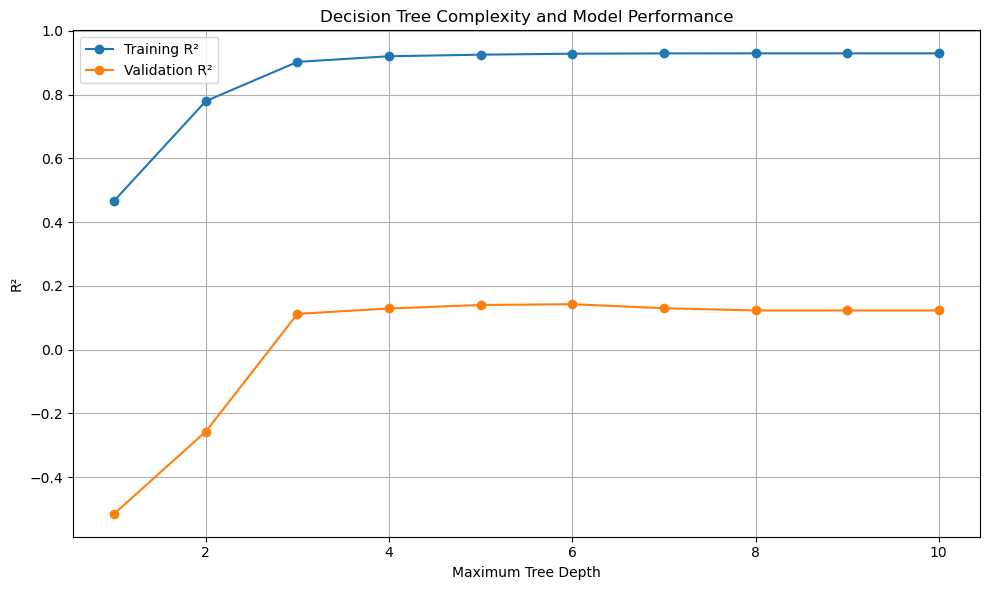

In [62]:
plt.figure(figsize=(10, 6))

plt.plot(
    depth_df["Depth"],
    depth_df["Train_R2"],
    marker="o",
    label="Training R²"
)

plt.plot(
    depth_df["Depth"],
    depth_df["Validation_R2"],
    marker="o",
    label="Validation R²"
)

plt.xlabel("Maximum Tree Depth")
plt.ylabel("R²")
plt.title("Decision Tree Complexity and Model Performance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Investigating Prediction Failures 

In [63]:
# Selecting the best model based on cross-validated RMSE

best_model_name = results_df.loc[
    results_df["Validation RMSE"].idxmin(),
    "Model"
]

best_model = models[best_model_name]

print("Selected model:", best_model_name)

Selected model: Random Forest


In [64]:
# Generating out-of-fold predictions
oof_predictions = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv,
    method="predict",
    n_jobs=-1
)

print("Out-of-fold predictions generated:", len(oof_predictions))

Out-of-fold predictions generated: 120


In [65]:
# Creating prediction error dataframe

error_df = df.copy()

error_df["Actual_price"] = y.values
error_df["Predicted_price"] = oof_predictions

# Positive error = model underpredicted the actual price
error_df["Prediction_error"] = (
    error_df["Actual_price"] -
    error_df["Predicted_price"]
)

error_df["Absolute_error"] = (
    error_df["Prediction_error"].abs()
)

error_df["Percentage_error"] = (
    error_df["Absolute_error"] /
    error_df["Actual_price"] * 100
)

error_df["Prediction_error"] = error_df["Prediction_error"].round(2)
error_df["Absolute_error"] = error_df["Absolute_error"].round(2)
error_df["Percentage_error"] = error_df["Percentage_error"].round(2)

In [66]:
# Identifing the five largest prediction errors
top_5_errors = (
    error_df
    .nlargest(5, "Absolute_error")
    .copy()
)

top_5_errors[
    [
        "Address",
        "Locality",
        "Property_type",
        "Sale_date",
        "Bed",
        "Bath",
        "Parking",
        "Distance_from_school_km",
        "Actual_price",
        "Predicted_price",
        "Prediction_error",
        "Absolute_error",
        "Percentage_error"
    ]
]

,Address,Locality,Property_type,Sale_date,Bed,Bath,Parking,Distance_from_school_km,Actual_price,Predicted_price,Prediction_error,Absolute_error,Percentage_error
67,"5 Botanic Road, Mosman NSW 2088",Mosman,House,2026-07-22,4,3,2.00,0.50,8700000,2527000.43,6172999.57,6172999.57,70.95
19,"2 Morella Road, Mosman NSW 2088",Mosman,House,2026-06-05,5,4,4.00,1.60,7360000,3564928.69,3795071.31,3795071.31,51.56
27,"5 Central Avenue, Mosman NSW 2088",Mosman,House,2026-06-19,5,4,2.00,0.20,6399000,3588679.29,2810320.71,2810320.71,43.92
12,"11 Euryalus Street, Mosman NSW 2088",Mosman,House,2026-06-04,6,4,3.00,0.30,7260000,4684353.54,2575646.46,2575646.46,35.48
21,"14 Almora Street, Mosman NSW 2088",Mosman,House,2026-06-06,3,2,2.00,0.80,5025000,2488104.36,2536895.64,2536895.64,50.49


In [67]:
# identifing the largest percentage errors
top_5_percentage_errors = (
    error_df
    .nlargest(5, "Percentage_error")
    .copy()
)

top_5_percentage_errors[
    [
        "Address",
        "Locality",
        "Property_type",
        "Actual_price",
        "Predicted_price",
        "Absolute_error",
        "Percentage_error"
    ]
]

,Address,Locality,Property_type,Actual_price,Predicted_price,Absolute_error,Percentage_error
48,"43 Stewart Avenue, Blacktown NSW 2148",Blacktown,House,1305000,2738024.46,1433024.46,109.81
37,"901/5 Second Avenue, Blacktown NSW 2148",Blacktown,Apartment / Unit / Flat,440000,845854.37,405854.37,92.24
103,"12 Siebel Street, Blacktown NSW 2148",Blacktown,House,1080000,2020983.94,940983.94,87.13
3,"2/78 Shadforth Street, Mosman NSW 2088",Mosman,Apartment / Unit / Flat,785000,1455063.65,670063.65,85.36
64,"1/32 Hassall Street, Parramatta NSW 2150",Parramatta,Apartment / Unit / Flat,350000,602636.23,252636.23,72.18


In [68]:
# identifing the largest percentage errors by Property_description
top_5_errors[
    [
        "Address",
        "Locality",
        "Property_type",
        "Bed",
        "Bath",
        "Parking",
        "Distance_from_school_km",
        "Actual_price",
        "Predicted_price",
        "Absolute_error",
        "Percentage_error",
        "Property_description"
    ]
].T

,67,19,27,12,21
Address,"5 Botanic Road, Mosman NSW 2088","2 Morella Road, Mosman NSW 2088","5 Central Avenue, Mosman NSW 2088","11 Euryalus Street, Mosman NSW 2088","14 Almora Street, Mosman NSW 2088"
Locality,Mosman,Mosman,Mosman,Mosman,Mosman
Property_type,House,House,House,House,House
Bed,4,5,5,6,3
Bath,3,4,4,4,2
Parking,2.00,4.00,2.00,3.00,2.00
Distance_from_school_km,0.50,1.60,0.20,0.30,0.80
Actual_price,8700000,7360000,6399000,7260000,5025000
Predicted_price,2527000.43,3564928.69,3588679.29,4684353.54,2488104.36
Absolute_error,6172999.57,3795071.31,2810320.71,2575646.46,2536895.64


In [69]:
# error table
part4_summary = top_5_errors[
    [
        "Address",
        "Locality",
        "Property_type",
        "Sale_date",
        "Bed",
        "Bath",
        "Parking",
        "Distance_from_school_km",
        "Actual_price",
        "Predicted_price",
        "Prediction_error",
        "Absolute_error",
        "Percentage_error"
    ]
].copy()

part4_summary.T

,67,19,27,12,21
Address,"5 Botanic Road, Mosman NSW 2088","2 Morella Road, Mosman NSW 2088","5 Central Avenue, Mosman NSW 2088","11 Euryalus Street, Mosman NSW 2088","14 Almora Street, Mosman NSW 2088"
Locality,Mosman,Mosman,Mosman,Mosman,Mosman
Property_type,House,House,House,House,House
Sale_date,2026-07-22 00:00:00,2026-06-05 00:00:00,2026-06-19 00:00:00,2026-06-04 00:00:00,2026-06-06 00:00:00
Bed,4,5,5,6,3
Bath,3,4,4,4,2
Parking,2.00,4.00,2.00,3.00,2.00
Distance_from_school_km,0.50,1.60,0.20,0.30,0.80
Actual_price,8700000,7360000,6399000,7260000,5025000
Predicted_price,2527000.43,3564928.69,3588679.29,4684353.54,2488104.36


In [70]:
# investigating the top five error properties individually
def investigate_property(row):
    
    print("=" * 90)
    print("PROPERTY:", row["Address"])
    print("=" * 90)
    
    print("\nLocation:", row["Locality"])
    print("Property type:", row["Property_type"])
    print("Sale date:", row["Sale_date"])
    
    print("\nProperty characteristics:")
    print("Bedrooms:", row["Bed"])
    print("Bathrooms:", row["Bath"])
    print("Parking:", row["Parking"])
    print(
        "Distance from school:",
        row["Distance_from_school_km"],
        "km"
    )
    
    print("\nPrediction:")
    print("Actual price:    ${:,.0f}".format(row["Actual_price"]))
    print("Predicted price: ${:,.0f}".format(row["Predicted_price"]))
    print("Absolute error:  ${:,.0f}".format(row["Absolute_error"]))
    print("Percentage error: {:.2f}%".format(row["Percentage_error"]))
    
    if row["Prediction_error"] > 0:
        print("Direction: Model UNDERPREDICTED the property")
    else:
        print("Direction: Model OVERPREDICTED the property")
    
    print("\nProperty description:")
    print(row["Property_description"])

In [71]:
for _, row in top_5_errors.iterrows():
    investigate_property(row)

PROPERTY: 5 Botanic Road, Mosman NSW 2088

Location: Mosman
Property type: House
Sale date: 2026-07-22 00:00:00

Property characteristics:
Bedrooms: 4
Bathrooms: 3
Parking: 2.0
Distance from school: 0.5 km

Prediction:
Actual price:    $8,700,000
Predicted price: $2,527,000
Absolute error:  $6,173,000
Percentage error: 70.95%
Direction: Model UNDERPREDICTED the property

Property description:
just a short and level stroll to the sand of balmoral beach and set in the most private and tranquil setting, this innovative easy-care residence captures contemporary family living at its finest. architect designed and benefitted by a wide 20m frontage, generous living and dining areas open seamlessly onto a spacious and private entertaining terrace overlooking the lap pool and landscaped gardens.

full-brick construction and with 'smart home' technology throughout, the residence offers a superbly styled home with true balance and harmony. filled with light, peace, and bespoke joinery, every oppo

In [72]:
# description-derived characteristics of top five error properties
top_5_errors[
    [
        "Address",
        "Locality",
        "Property_type",
        "Actual_price",
        "Predicted_price",
        "Absolute_error"
    ] + description_features
].T

,67,19,27,12,21
Address,"5 Botanic Road, Mosman NSW 2088","2 Morella Road, Mosman NSW 2088","5 Central Avenue, Mosman NSW 2088","11 Euryalus Street, Mosman NSW 2088","14 Almora Street, Mosman NSW 2088"
Locality,Mosman,Mosman,Mosman,Mosman,Mosman
Property_type,House,House,House,House,House
Actual_price,8700000,7360000,6399000,7260000,5025000
Predicted_price,2527000.43,3564928.69,3588679.29,4684353.54,2488104.36
Absolute_error,6172999.57,3795071.31,2810320.71,2575646.46,2536895.64
Has_pool,1,1,1,1,0
Has_garage,1,0,1,1,0
Has_balcony,0,0,1,0,0
Has_garden,0,0,1,0,0


In [73]:
# calculating errors for every property
error_df[
    [
        "Property_type",
        "Locality",
        "Absolute_error",
        "Percentage_error"
    ]
].groupby("Property_type").agg(
    Count=("Absolute_error", "count"),
    Mean_absolute_error=("Absolute_error", "mean"),
    Median_absolute_error=("Absolute_error", "median"),
    Mean_percentage_error=("Percentage_error", "mean")
).sort_values(
    "Mean_absolute_error",
    ascending=False
)

,Count,Mean_absolute_error,Median_absolute_error,Mean_percentage_error
Property_type,,,,
House,36,927082.71,414965.84,33.70
Townhouse,5,242648.78,214756.39,15.07
Apartment / Unit / Flat,79,163084.54,116833.50,22.49


In [74]:
# calculate errors by suburbs
error_df.groupby("Locality").agg(
    Count=("Absolute_error", "count"),
    Mean_absolute_error=("Absolute_error", "mean"),
    Median_absolute_error=("Absolute_error", "median"),
    Mean_percentage_error=("Percentage_error", "mean")
).sort_values(
    "Mean_absolute_error",
    ascending=False
)

,Count,Mean_absolute_error,Median_absolute_error,Mean_percentage_error
Locality,,,,
Mosman,40,812494.06,317095.54,28.09
Blacktown,40,284523.90,169101.03,32.59
Parramatta,40,89779.55,66355.18,15.96


In [75]:
# Checking whether expensive properties are harder to predict
error_df["Price_quartile"] = pd.qcut(
    error_df["Actual_price"],
    q=4,
    labels=[
        "Lowest 25%",
        "25%-50%",
        "50%-75%",
        "Highest 25%"
    ]
)

error_by_price = error_df.groupby(
    "Price_quartile",
    observed=True
).agg(
    Count=("Absolute_error", "count"),
    Mean_absolute_error=("Absolute_error", "mean"),
    Median_absolute_error=("Absolute_error", "median"),
    Mean_percentage_error=("Percentage_error", "mean")
)

error_by_price

,Count,Mean_absolute_error,Median_absolute_error,Mean_percentage_error
Price_quartile,,,,
Lowest 25%,30,142671.26,144836.01,30.72
25%-50%,30,130918.94,58196.84,16.94
50%-75%,30,265225.37,167222.77,26.13
Highest 25%,30,1043581.10,324361.40,28.38


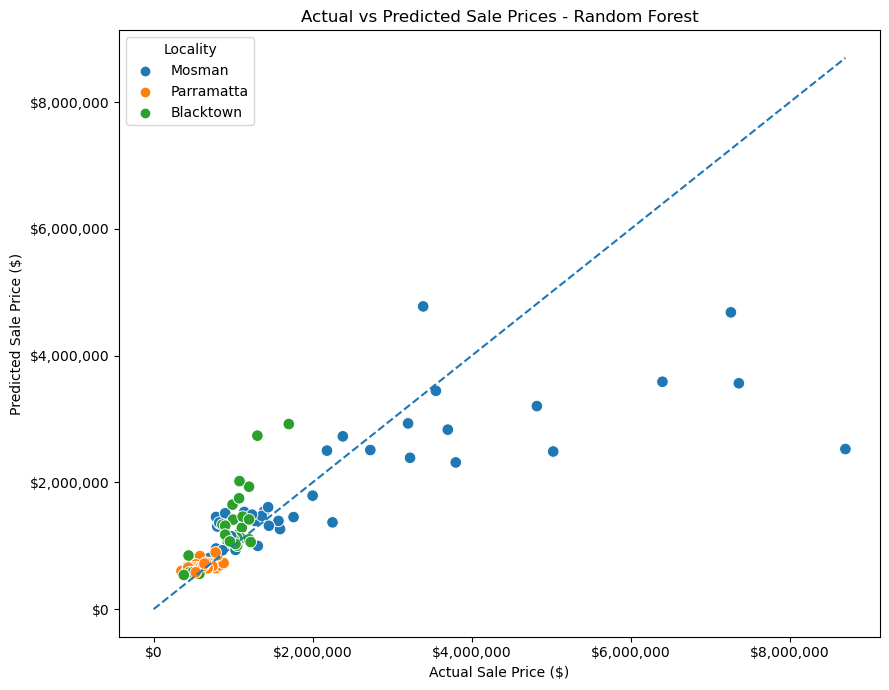

In [76]:
# predicted-versus-actual plot
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=error_df,
    x="Actual_price",
    y="Predicted_price",
    hue="Locality",
    s=70
)

max_price = max(
    error_df["Actual_price"].max(),
    error_df["Predicted_price"].max()
)

plt.plot(
    [0, max_price],
    [0, max_price],
    linestyle="--"
)

plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.title(
    f"Actual vs Predicted Sale Prices - {best_model_name}"
)

plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('${x:,.0f}')
)

plt.gca().yaxis.set_major_formatter(
    ticker.StrMethodFormatter('${x:,.0f}')
)

plt.tight_layout()
plt.show()

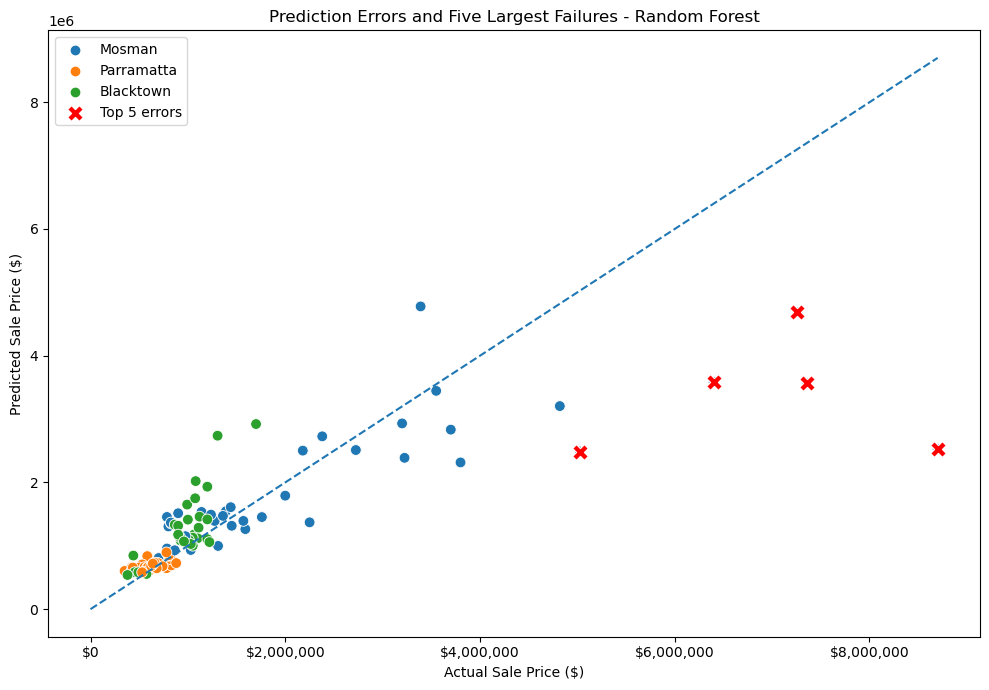

In [77]:
# highlighting the five largest failures
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=error_df,
    x="Actual_price",
    y="Predicted_price",
    hue="Locality",
    s=60
)

sns.scatterplot(
    data=top_5_errors,
    x="Actual_price",
    y="Predicted_price",
    color="red",
    s=130,
    marker="X",
    label="Top 5 errors"
)

max_price = max(
    error_df["Actual_price"].max(),
    error_df["Predicted_price"].max()
)

plt.plot(
    [0, max_price],
    [0, max_price],
    linestyle="--"
)

plt.xlabel("Actual Sale Price ($)")
plt.ylabel("Predicted Sale Price ($)")
plt.title(
    f"Prediction Errors and Five Largest Failures - {best_model_name}"
)

plt.gca().xaxis.set_major_formatter(
    ticker.StrMethodFormatter('${x:,.0f}')
)

plt.tight_layout()
plt.show()

In [78]:
# Separating features and target
X = df[features].copy()
y = df["Sell_price"].copy()

# Creating training and held-out test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training observations:", len(X_train))
print("Held-out test observations:", len(X_test))

Training observations: 96
Held-out test observations: 24


In [79]:
# selecting ten properties from the test set
test_indices = X_test.sample(
    n=10,
    random_state=42
).index

In [80]:
# Creating the ten-property dataset
part5_test = df.loc[test_indices].copy()

part5_test[
    [
        "Address",
        "Locality",
        "Property_type",
        "Bed",
        "Bath",
        "Parking",
        "Distance_from_school_km",
        "Sell_price",
        "Property_description"
    ]
]

,Address,Locality,Property_type,Bed,Bath,Parking,Distance_from_school_km,Sell_price,Property_description
40,"509/8B Allawah Street, Blacktown NSW 2148",Blacktown,Apartment / Unit / Flat,3,2,2.00,0.80,760000,"experience the perfect blend of style, space and convenience in this modern 3-bedroom, 2-bathroo..."
109,"57 Walters Road, Blacktown NSW 2148",Blacktown,House,3,1,1.00,1.00,1221000,"located within walking distance to premier schools, shops, transport and in one of the districts..."
44,"4/3 Millett Road, Mosman NSW 2088",Mosman,Apartment / Unit / Flat,2,1,1.00,0.80,1050000,"tucked away in a leafy, private setting, this beautifully renovated two-bedroom apartment offers..."
88,"53 - 53A Pelleas Street, Blacktown NSW 2148",Blacktown,House,7,4,2.00,0.40,1700000,presented to the market by your leading agency sky property is this stunning double-storey resid...
62,"8 Prospect Street, Blacktown NSW 2148",Blacktown,House,3,1,1.00,0.70,1050000,"positioned in a highly convenient and well-connected pocket of blacktown, this tidy family home ..."
107,"29/17-19 Third Avenue, Blacktown NSW 2148",Blacktown,Apartment / Unit / Flat,2,1,1.00,0.40,455000,sky property are excited to present this immaculately presented neat and tidy ultra rare solid u...
36,"7/154 Raglan Street, Mosman NSW 2088",Mosman,Apartment / Unit / Flat,1,1,1.00,0.40,785000,"positioned privately on the top floor within a double brick complex, this newly renovated one-be..."
47,"804/140 Church Street, Parramatta NSW 2150",Parramatta,Apartment / Unit / Flat,2,2,1.00,0.30,660000,"experience elevated urban living in this exquisite two-bedroom apartment, positioned on the 8th ..."
45,"52/7 Griffiths Street, Blacktown NSW 2148",Blacktown,Apartment / Unit / Flat,2,1,1.00,0.90,410000,"umang and team urbane real estate presents this modern 2-bedroom, 1-bathroom apartment with 1 ca..."
64,"1/32 Hassall Street, Parramatta NSW 2150",Parramatta,Apartment / Unit / Flat,1,1,NaN,0.30,350000,"positioned in a prime central location, this well-appointed 1-bedroom apartment offers the perfe..."


In [81]:
best_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Bed', 'Bath', 'Parking',
                                                   'Distance_from_school_km',
                                                   'Sale_year',
                                                   'Sale_month_num',
                                                   'Sale_quarter',
                                                   'Bath_per_Bed',
                                                   'Bed_Bath_Total', 'Has_pool',
                                                   'Has_garage', 'Has_balcony',
                                                   'Has_garden', 'Has_views'...
                                                   'Has_aircon', 'Has_ensuite',
                                                   'Has_builtins',
                                                   'Has_courtyard']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Locality',
                                                   'Property_type'])])),
                ('model',
                 RandomForestRegressor(max_depth=6, max_features='sqrt',
                                       min_samples_leaf=3, n_estimators=300,
                                       n_jobs=-1, random_state=42))])

In [82]:
X_part5 = X_test.loc[test_indices]

ml_predictions = best_model.predict(X_part5)

In [83]:
part5_results = df.loc[test_indices, [
    "Address",
    "Locality",
    "Property_type",
    "Bed",
    "Bath",
    "Parking",
    "Distance_from_school_km",
    "Sell_price",
    "Property_description"
]].copy()

part5_results["ML_prediction"] = ml_predictions

In [84]:
# exporting train and test 10 property dataset for human judgement and llm
X_train.to_excel(
    "..\\Data\\training_dataset.xlsx",
    index=False
)

y_train.to_excel(
    "..\\Data\\training_target.xlsx",
    index=False
)

X_part5.to_excel(
    "..\\Data\\test_dataset.xlsx",
    index=False
)


print(f"Model datasets saved")

Model datasets saved


In [85]:
part5_results["Human_estimate"] = [
    600000,
    1030000,
    954165,
    1920000,
    1236000,
    341664,
    764580,
    1064680,
    359296,
    533125
]

In [86]:
part5_results["LLM_prediction"] = [
    575000,
    977500,
    1300000,
    1300000,
    950000,
    525000,
    850000,
    800000,
    475000,
    525000
]

In [87]:
# calculating errors consistently
prediction_methods = [
    "ML_prediction",
    "LLM_prediction",
    "Human_estimate"
]

for method in prediction_methods:

    part5_results[f"{method}_error"] = (
        part5_results[method] -
        part5_results["Sell_price"]
    )

    part5_results[f"{method}_absolute_error"] = (
        part5_results[f"{method}_error"].abs()
    )

    part5_results[f"{method}_percentage_error"] = (
        part5_results[f"{method}_absolute_error"] /
        part5_results["Sell_price"] * 100
    )

In [88]:
# comparison table
comparison_table = part5_results[
    [
        "Address",
        "Locality",
        "Property_type",
        "Sell_price",
        "ML_prediction",
        "LLM_prediction",
        "Human_estimate"
    ]
].copy()

comparison_table

,Address,Locality,Property_type,Sell_price,ML_prediction,LLM_prediction,Human_estimate
40,"509/8B Allawah Street, Blacktown NSW 2148",Blacktown,Apartment / Unit / Flat,760000,758739.24,575000,600000
109,"57 Walters Road, Blacktown NSW 2148",Blacktown,House,1221000,1061432.80,977500,1030000
44,"4/3 Millett Road, Mosman NSW 2088",Mosman,Apartment / Unit / Flat,1050000,1106836.22,1300000,954165
88,"53 - 53A Pelleas Street, Blacktown NSW 2148",Blacktown,House,1700000,3174881.98,1300000,1920000
62,"8 Prospect Street, Blacktown NSW 2148",Blacktown,House,1050000,1018315.23,950000,1236000
107,"29/17-19 Third Avenue, Blacktown NSW 2148",Blacktown,Apartment / Unit / Flat,455000,579274.24,525000,341664
36,"7/154 Raglan Street, Mosman NSW 2088",Mosman,Apartment / Unit / Flat,785000,980433.58,850000,764580
47,"804/140 Church Street, Parramatta NSW 2150",Parramatta,Apartment / Unit / Flat,660000,725700.70,800000,1064680
45,"52/7 Griffiths Street, Blacktown NSW 2148",Blacktown,Apartment / Unit / Flat,410000,609758.39,475000,359296
64,"1/32 Hassall Street, Parramatta NSW 2150",Parramatta,Apartment / Unit / Flat,350000,596144.68,525000,533125


In [89]:
# error comparison table
error_comparison = pd.DataFrame({
    "Method": [
        "Machine Learning",
        "Large Language Model",
        "Human Judgement"
    ],

    "MAE": [
        part5_results["ML_prediction_absolute_error"].mean(),
        part5_results["LLM_prediction_absolute_error"].mean(),
        part5_results["Human_estimate_absolute_error"].mean()
    ],

    "RMSE": [
        np.sqrt(
            np.mean(
                part5_results["ML_prediction_error"] ** 2
            )
        ),
        np.sqrt(
            np.mean(
                part5_results["LLM_prediction_error"] ** 2
            )
        ),
        np.sqrt(
            np.mean(
                part5_results["Human_estimate_error"] ** 2
            )
        )
    ],

    "Mean Percentage Error": [
        part5_results["ML_prediction_percentage_error"].mean(),
        part5_results["LLM_prediction_percentage_error"].mean(),
        part5_results["Human_estimate_percentage_error"].mean()
    ]
})

error_comparison

,Method,MAE,RMSE,Mean Percentage Error
0,Machine Learning,255554.25,486150.18,28.96
1,Large Language Model,169350.00,197380.91,21.19
2,Human Judgement,162510.00,191675.49,23.00


In [90]:
error_columns = {
    "Machine Learning": "ML_prediction_absolute_error",
    "LLM": "LLM_prediction_absolute_error",
    "Human Judgement": "Human_estimate_absolute_error"
}

part5_results["Best_method"] = (
    part5_results[list(error_columns.values())]
    .rename(columns={
        value: key for key, value in error_columns.items()
    })
    .idxmin(axis=1)
)

part5_results[
    [
        "Address",
        "Sell_price",
        "ML_prediction",
        "LLM_prediction",
        "Human_estimate",
        "Best_method"
    ]
]

,Address,Sell_price,ML_prediction,LLM_prediction,Human_estimate,Best_method
40,"509/8B Allawah Street, Blacktown NSW 2148",760000,758739.24,575000,600000,Machine Learning
109,"57 Walters Road, Blacktown NSW 2148",1221000,1061432.80,977500,1030000,Machine Learning
44,"4/3 Millett Road, Mosman NSW 2088",1050000,1106836.22,1300000,954165,Machine Learning
88,"53 - 53A Pelleas Street, Blacktown NSW 2148",1700000,3174881.98,1300000,1920000,Human Judgement
62,"8 Prospect Street, Blacktown NSW 2148",1050000,1018315.23,950000,1236000,Machine Learning
107,"29/17-19 Third Avenue, Blacktown NSW 2148",455000,579274.24,525000,341664,LLM
36,"7/154 Raglan Street, Mosman NSW 2088",785000,980433.58,850000,764580,Human Judgement
47,"804/140 Church Street, Parramatta NSW 2150",660000,725700.70,800000,1064680,Machine Learning
45,"52/7 Griffiths Street, Blacktown NSW 2148",410000,609758.39,475000,359296,Human Judgement
64,"1/32 Hassall Street, Parramatta NSW 2150",350000,596144.68,525000,533125,LLM


In [91]:
part5_results["Best_method"].value_counts()

Best_method
Machine Learning    5
Human Judgement     3
LLM                 2
Name: count, dtype: int64

In [92]:
# calculating bias
bias_comparison = pd.DataFrame({
    "Method": [
        "Machine Learning",
        "LLM",
        "Human Judgement"
    ],

    "Mean Error": [
        part5_results["ML_prediction_error"].mean(),
        part5_results["LLM_prediction_error"].mean(),
        part5_results["Human_estimate_error"].mean()
    ]
})

bias_comparison

,Method,Mean Error
0,Machine Learning,217051.71
1,LLM,-16350.00
2,Human Judgement,36251.00


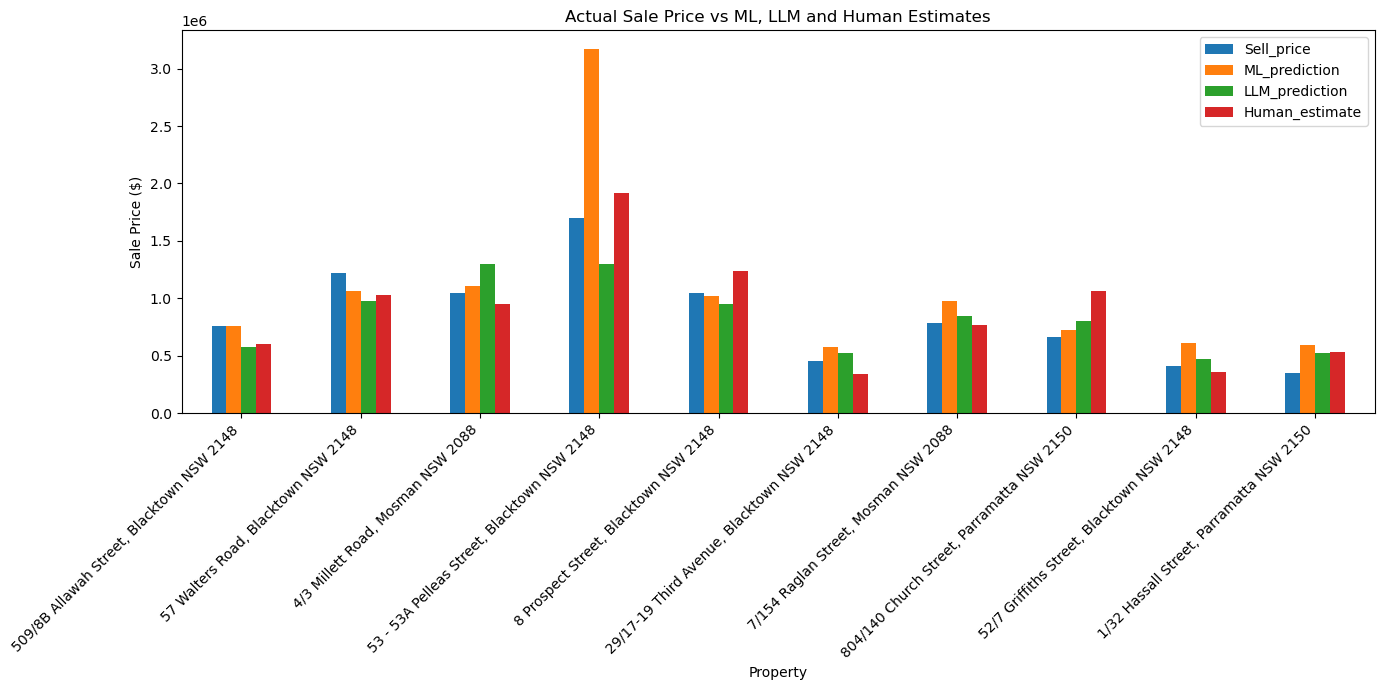

In [93]:
# plotting 3 approaches
plot_df = part5_results[
    [
        "Address",
        "Sell_price",
        "ML_prediction",
        "LLM_prediction",
        "Human_estimate"
    ]
].copy()

plot_df = plot_df.set_index("Address")

plot_df.plot(
    kind="bar",
    figsize=(14, 7)
)

plt.ylabel("Sale Price ($)")
plt.xlabel("Property")
plt.title(
    "Actual Sale Price vs ML, LLM and Human Estimates"
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [94]:
# saving the final model
import joblib

# Fit final model on the training data
best_model.fit(X_train, y_train)

# Save the complete preprocessing + modelling pipeline
joblib.dump(
    best_model,
    "..\\Model\\property_price_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.
